In [1]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [2]:
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_neu.pkl', "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']


N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
<>:2: SyntaxWarning: invalid escape sequence '\J'
<>:12: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_31424\3800015342.py:2: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_neu.pkl', "rb") as input_file:
C:\Users\katie\AppData\Local\Temp\ipykernel_31424\3800015342.py:12: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[11 23  3 22  2 12  5  6 15  9 20 10 14 26  7 25 19 24 13  4 18 17]
>>> best_lam returning: 20.30917620904739


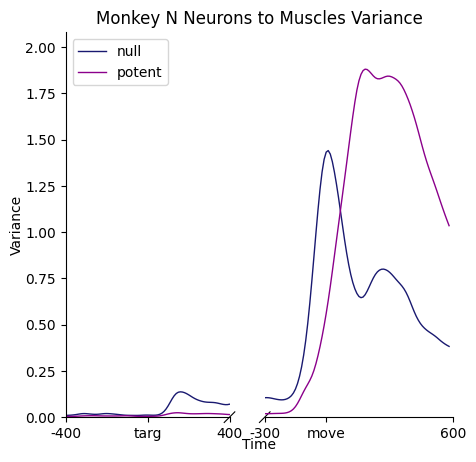

In [3]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[ 8 16 22  4  6 12  9 11 21 19  2 26  5 25 13 15  0 23 18 10 17 20]
>>> best_lam returning: 20.30917620904739


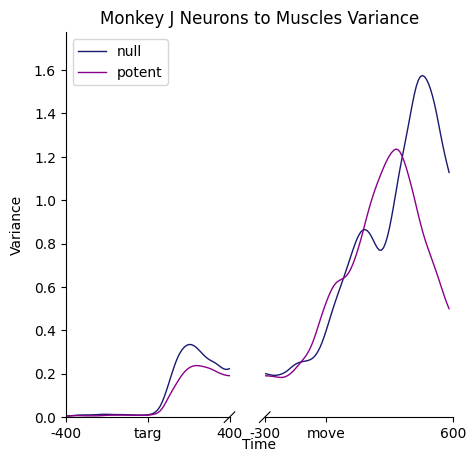

In [12]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[22 21 15  9 12 17 13 18  1 23 11  0  4  2 14 26  6  5 24 25 10  3]
>>> best_lam returning: 20.30917620904739


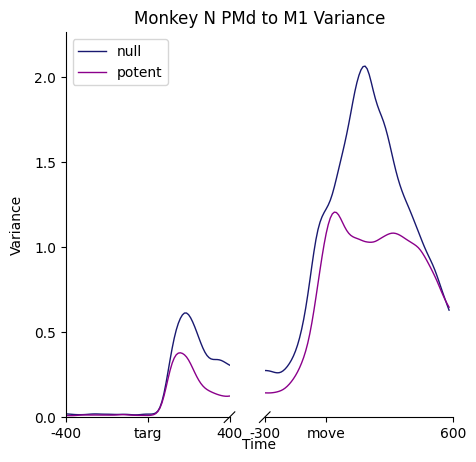

In [15]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[ 53  54  48  50  93  78  33  90  87   4  72  69  20 103   5  23  35  17
  99  75 106  67  98  18  22  95  61  62  49  42  59  10  60  32  19   9
  55  86  40  58  79 100  97  45  34  83 105  85  81  21  66  52  68  29
  41  47   0  70 101  92  71  37  28  43  63  76  39  73  27  13  51 102
 104   1  14  80  82  31  25  11  74  88  24  15   7  77  16]
>>> best_lam returning: 20.30917620904739


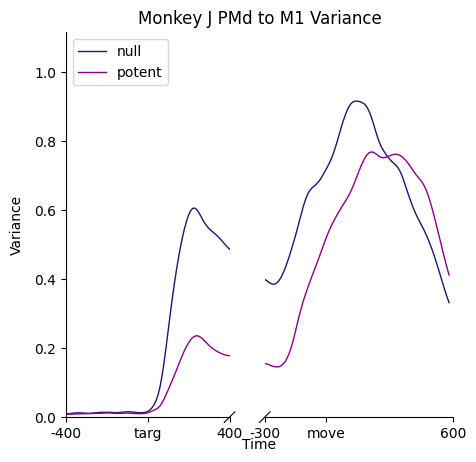

In [19]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 97  67  75  32   2  89  25  88  68  98  37   0  63 106  40  39  84  17
  96  55  76  15  22  28 103   9   8  93  60  26  10  19  45  94  99  30
 102  42  91  72  49  73  69   4  52  90   7  20  33 107  56  21  34  74
 104  41  82  38  47  62  31  64  61 101  50  77   1  48  78  87 100  79
  83  16  95  80  92  46  14  53  51  18  66  59  27  86  54]
>>> best_lam returning: 20.30917620904739


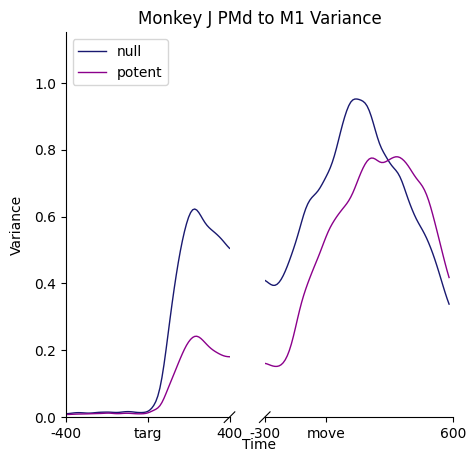

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[26 22 17  9 10 11 25 12 23  5  3 24 13  2  0 14 19  7 18 15 20  6]
>>> best_lam returning: 34.55107294592218


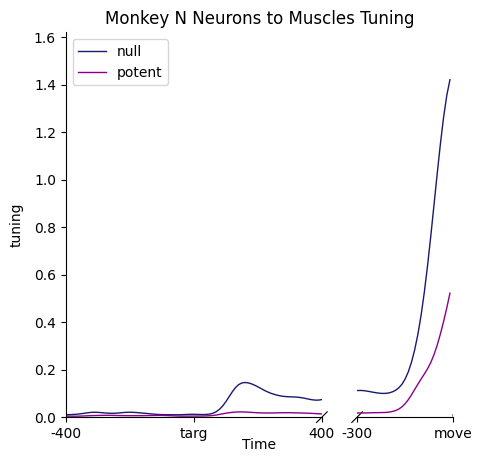

In [8]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [9]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)